In [50]:
'''
spark ok? (tentar dnv no fim)
algoritmo de agrupamento ok (qtd clusters*) ok
análise de cada cluster* ok
PCA aplicado
refinar análise (variância acumulada, exp pc, *resultado-salvar csv)
grafico 2d(separar clusters e ver tipos/ separar C1 e c2), grafico 3d)


Avaliar usar pokedex normal?

'''

'\nspark ok? (tentar dnv no fim)\nalgoritmo de agrupamento ok (qtd clusters*) ok\nanálise de cada cluster* ok\nPCA aplicado\nrefinar análise (variância acumulada, exp pc, *resultado-salvar csv)\ngrafico 2d(separar clusters e ver tipos/ separar C1 e c2), grafico 3d)\n\n\nAvaliar usar pokedex normal?\n\n'

In [51]:
#from ucimlrepo import fetch_ucirepo 
import random
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import seaborn as sns
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession
import os
import scipy.linalg as la
sns.set(style='whitegrid')
from sklearn.decomposition import PCA
from sklearn.preprocessing import scale

# Fuzzy C-Means (T1)

In [52]:
# 1° Passo - Montar Matriz W com sorteio
def matriz_w(X, clusters):
    W = []

    # Teremos que fazer o sorteio de 'clusters' valores 150 vezes (tamanho da iris)
    for linha in range(len(X)):
        # Gerando 'clusters' números aleatórios
        prob = [random.random() for _ in range(clusters)]

        # Transformando em entre 0 e 1 (percentual)
        prob_normalizados = [x / sum(prob) for x in prob]
        
        W.append(prob_normalizados)
        
    W = pd.DataFrame(W, columns=[f'C{i}' for i in range(1, clusters + 1)])
    return W 

# 2° Passo - Calcular o centróide dos cluster
def calcular_centroides(X, W):
    # Pegando a variável xi (todos valores do df)
    xi = X.values
    
    centroides = []
    
    for col in W.columns:
        pesos = W[col].values
        
        # Aplicando a fórmula
        numerador = np.sum(xi * pesos[:, None], axis=0)
        denominador = np.sum(pesos)
        
        centroides.append(numerador / denominador)
    
    return np.array(centroides)

# 3° Passo - Atualizar pesos

# Função de distância Euclidiana
def dist(a, b):
    return np.linalg.norm(a - b)

# Função para atualizar os pesos
def att_pesos(centroides, X, m):
    novos_pesos = []
    # Pra cada linha, atualizaremos os pesos
    for _, linha in X.iterrows():
        # Extraindo os valores da linha
        xi = linha.values
        
        # Calculando a distância de cada centroide para essa linha
        distancias = [dist(xi, c) for c in centroides]
        
        probabilidade_att = []
        for d in distancias:
            # Se a distância for 0, o peso é 1
            if np.any(d == 0):
                probabilidade_att.append(1.0)
            else:
                soma_razões = sum([(d / d_2)**(2/(m-1)) for d_2 in distancias])
                probabilidade_att.append(1 / soma_razões)
                
        novos_pesos.append(probabilidade_att)

    # Atualizando a matriz W com os novos pesos calculados
    W = pd.DataFrame(novos_pesos, columns=[f'C{i+1}' for i in range(len(centroides))])
    return W


# 4° Passo - Função para classificar amostras

# Função para dar uma classe a partir de uma diff comparada com o threshold
# O threshold funcionará como um valor mínimo da diferença entre os clusters com maior probabilidade
def classificacao(W, threshold):
    classe = []
    
    for _, row in W.iterrows():
        valores = row.values
        
        # Ordena do maior pro menor para calcular a diff
        ordenados = np.sort(valores)[::-1]
        
        maior = ordenados[0]
        segundo = ordenados[1]
        
        diff = maior - segundo
        
        idx_max = valores.argmax()
        
        # Se a diff foi 'suficiente', classificamos
        if diff >= threshold:
            classe.append(f'cluster{idx_max}')
        else:
            classe.append('ruido')
    
    return np.array(classe)

# 5° Passo - Função final (mesclando tudo)

# Teremos um número máximo de iterações, mas ele poderá parar antes conforme o critério de parada pré-determinado  <----------------------
def fuzzy_c_means(X, clusters, threshold, m, max_iter=100):
    # Normalizando os valores de X usando min max
    scaler = MinMaxScaler()
    
    # Normalizando e voltando pra df
    X_norm = pd.DataFrame(
        scaler.fit_transform(X),
        columns=X.columns,
        index=X.index
    )
    
    centroides = []
    
    # Criando a matriz W
    W = matriz_w(X_norm, clusters)
    
    # Looping até atingir o critério de parada ou o máximo de iterações fornecido
    for i in range(max_iter):
        centroide_atual = calcular_centroides(X_norm, W)
        W = att_pesos(centroide_atual, X_norm, m)
        centroides.append(centroide_atual)

        # Critério de parada: se a diferença entre os centróides atuais e os anteriores for menor que 10^-3 e i != 0 (não tem valor para comparar na 1° iteração), então paramos
        if (i != 0) and (np.max(np.abs(np.array(centroides[-1]) - np.array(centroides[-2]))) < 1e-3):
            print(f'    Critério de parada atingido, com {i} iterações')
            break
        
    # Classificaremos através de um threshold que funcionará como um valor mínimo da diferença entre os clusters com maior probabilidade, os que não passarem receberão cluster 'ruido'
    y = classificacao(W, threshold)
    
    # Calcularemos também o Silhouette como métrica de avaliação
    # Primeiro é preciso tirar as classes ruído
    X_sem_ruido = X_norm[y != 'ruido']
    W_sem_ruido = W[y != 'ruido']
    
    # Verificar número de clusters válidos
    labels = W_sem_ruido.values.argmax(axis=1)
    labels_unicos = np.unique(labels)

    # Se não tiver classificado ninguém ou tiver apenas um cluster, silhouette é -1, caso contrário aplica o silhouette de fato
    if len(X_sem_ruido) == 0 or len(labels_unicos) < 2:
        silhouette = -1
    else: 
        silhouette = silhouette_score(X_sem_ruido, labels)
    
    return np.array(centroides), W, y, silhouette

# Processamento Dados Brutos

In [53]:
# https://www.kaggle.com/datasets/christofferms/pokemon-with-stats-and-image?resource=download
'''spark = SparkSession.builder.appName("Pokedex").getOrCreate()

# Leitura
df = spark.read.csv("pokedex_bruta.csv", header=True, inferSchema=True)

# Drop
df = df.drop("Image")

# Rename
df = (
    df.withColumnRenamed("Index", "num_pokedex")
      .withColumnRenamed("Name", "name")
      .withColumnRenamed("Type 1", "type_1")
      .withColumnRenamed("Type 2", "type_2")
      .withColumnRenamed("Total", "total")
      .withColumnRenamed("HP", "hp")
      .withColumnRenamed("Attack", "attack")
      .withColumnRenamed("Defense", "defense")
      .withColumnRenamed("SP. Atk.", "sp_atk")
      .withColumnRenamed("SP. Def", "sp_def")
      .withColumnRenamed("Speed", "speed")
)
# Dropando as variações por regiões Alola, Gallar, Hisui e forma Mega
df = df.dropDuplicates(["num_pokedex"])'''

'spark = SparkSession.builder.appName("Pokedex").getOrCreate()\n\n# Leitura\ndf = spark.read.csv("pokedex_bruta.csv", header=True, inferSchema=True)\n\n# Drop\ndf = df.drop("Image")\n\n# Rename\ndf = (\n    df.withColumnRenamed("Index", "num_pokedex")\n      .withColumnRenamed("Name", "name")\n      .withColumnRenamed("Type 1", "type_1")\n      .withColumnRenamed("Type 2", "type_2")\n      .withColumnRenamed("Total", "total")\n      .withColumnRenamed("HP", "hp")\n      .withColumnRenamed("Attack", "attack")\n      .withColumnRenamed("Defense", "defense")\n      .withColumnRenamed("SP. Atk.", "sp_atk")\n      .withColumnRenamed("SP. Def", "sp_def")\n      .withColumnRenamed("Speed", "speed")\n)\n# Dropando as variações por regiões Alola, Gallar, Hisui e forma Mega\ndf = df.dropDuplicates(["num_pokedex"])'

In [54]:
#df.show()

In [55]:
# https://www.kaggle.com/datasets/christofferms/pokemon-with-stats-and-image?resource=download
'''df = pd.read_csv('pokedex_bruta.csv')

# Dropando colunas que não serão utilizadas
df = df.drop(['Image'], axis=1)

df = df.rename(columns = {'Index':'num_pokedex', 'Name':'name', 'Type 1':'type_1', 'Type 2':'type_2', 'Total':'total', 'HP':'hp', 'Attack':'attack',
       'Defense':'defense', 'SP. Atk.':'sp_atk', 'SP. Def':'sp_def', 'Speed':'speed'})

df.to_csv('pokedex.csv', index=False)
# Type 1 e 2 --> 18'''

"df = pd.read_csv('pokedex_bruta.csv')\n\n# Dropando colunas que não serão utilizadas\ndf = df.drop(['Image'], axis=1)\n\ndf = df.rename(columns = {'Index':'num_pokedex', 'Name':'name', 'Type 1':'type_1', 'Type 2':'type_2', 'Total':'total', 'HP':'hp', 'Attack':'attack',\n       'Defense':'defense', 'SP. Atk.':'sp_atk', 'SP. Def':'sp_def', 'Speed':'speed'})\n\ndf.to_csv('pokedex.csv', index=False)\n# Type 1 e 2 --> 18"

In [56]:
# Fazendo a versão sem as variações por regiões Alola, Gallar, Hisui e forma Mega
'''df = pd.read_csv('pokedex.csv')
df = df.drop_duplicates(subset=['num_pokedex'])
df.to_csv('pokedex_filtrada.csv', index=False)'''

"df = pd.read_csv('pokedex.csv')\ndf = df.drop_duplicates(subset=['num_pokedex'])\ndf.to_csv('pokedex_filtrada.csv', index=False)"

# Algoritmo de Agrupamento

In [57]:
'''df = pd.read_csv('pokedex_filtrada.csv')
df.columns'''

"df = pd.read_csv('pokedex_filtrada.csv')\ndf.columns"

In [58]:
# Usaremos o Fuzzy C-Means aplicado no T1
# Com pandas
df = pd.read_csv('pokedex_filtrada.csv')
X = df[['total','hp', 'attack','defense', 'sp_atk', 'sp_def', 'speed']]

# Com Spark
'''X = df.select('total', 'hp', 'attack','defense', 'sp_atk','sp_def', 'speed')

# Convertendo X para pandas pq assim a função funcionará
X = X.toPandas()'''

# Definindo os parâmetros
threshold = 0.65
qtd_cluster = 4
max_iter = 200
coefs_silhouette = []

# Variaremos o m de 1.1 a 3 de 0.1 em 0.1 para determinal qual a melhor opção através do coef silhouette e quantidade de ruídos
ms = np.arange(1.1, 3.1, 0.1).round(1)

# Variaremos o m conforme a lista
for m in ms:
    cent, W, y, silhouette = fuzzy_c_means(X, qtd_cluster, threshold, m, max_iter)
    
    # Adicionando a classificação a matriz W
    W['Class'] = y
    
    # Salvado algumas variáveis para avaliação
    n = len(W)
    ruido = len(W[W['Class'] == 'ruido'])
    prop_ruido = ruido / n

    # Ponderando a quantidade de ruído junto ao coeficiente de silhouette
    score = silhouette * (1 - prop_ruido)
    coefs_silhouette.append([m, ruido, silhouette, score]) 

    print(f"        m = {m} | Ruídos = {ruido} | Silhouette = {silhouette:.4f} | Score: {score:.4f}")

# Depois de rodar todos, precisamos bater o martelo para o melhor, nesse caso usando o coeficiente silhouette combinado com o ruído (score)
melhor = max(coefs_silhouette, key=lambda x: x[3])
melhor_m = melhor[0]
melhor_ruido = melhor[1]
melhor_silhouette = melhor[2]
melhor_score = melhor[3]

# Salvando as variáveis finais
print(f'\n\nDito isso, m = {melhor_m} apresentou o melhor coeficiente silhouette combinado com o ruído ({melhor_score:.4f})')

# Aplicando o modelo final com os melhores hiperparâmetros
cent, W, y, silhouette = fuzzy_c_means(X, qtd_cluster, threshold, melhor_m, max_iter)

    Critério de parada atingido, com 20 iterações
        m = 1.1 | Ruídos = 103 | Silhouette = 0.2789 | Score: 0.2509
    Critério de parada atingido, com 25 iterações
        m = 1.2 | Ruídos = 191 | Silhouette = 0.3048 | Score: 0.2480
    Critério de parada atingido, com 17 iterações
        m = 1.3 | Ruídos = 313 | Silhouette = 0.3395 | Score: 0.2359
    Critério de parada atingido, com 21 iterações
        m = 1.4 | Ruídos = 449 | Silhouette = 0.3610 | Score: 0.2029
    Critério de parada atingido, com 25 iterações
        m = 1.5 | Ruídos = 654 | Silhouette = 0.3333 | Score: 0.1206
    Critério de parada atingido, com 32 iterações
        m = 1.6 | Ruídos = 735 | Silhouette = -1.0000 | Score: -0.2829
    Critério de parada atingido, com 33 iterações
        m = 1.7 | Ruídos = 766 | Silhouette = -1.0000 | Score: -0.2527
    Critério de parada atingido, com 35 iterações
        m = 1.8 | Ruídos = 843 | Silhouette = -1.0000 | Score: -0.1776
    Critério de parada atingido, com 2 ite

# Visualização dos Clusters

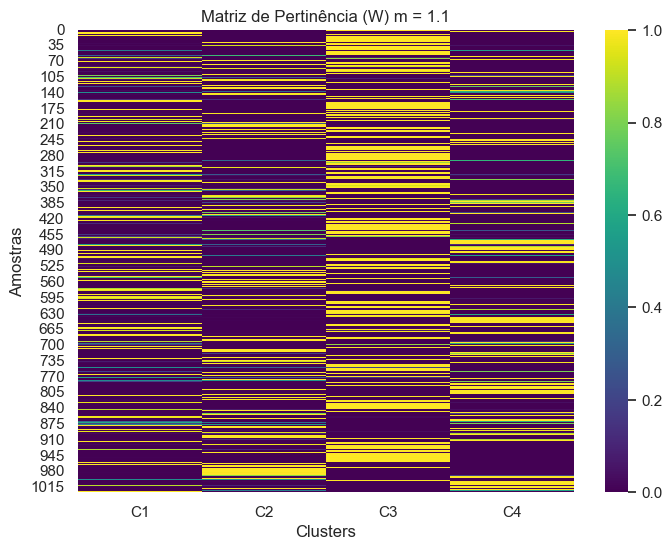

In [59]:
# Mostrando a pertinência através de um heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(W, cmap='viridis')

plt.title(f'Matriz de Pertinência (W) m = {melhor_m}')
plt.xlabel('Clusters')
plt.ylabel('Amostras')

plt.show()

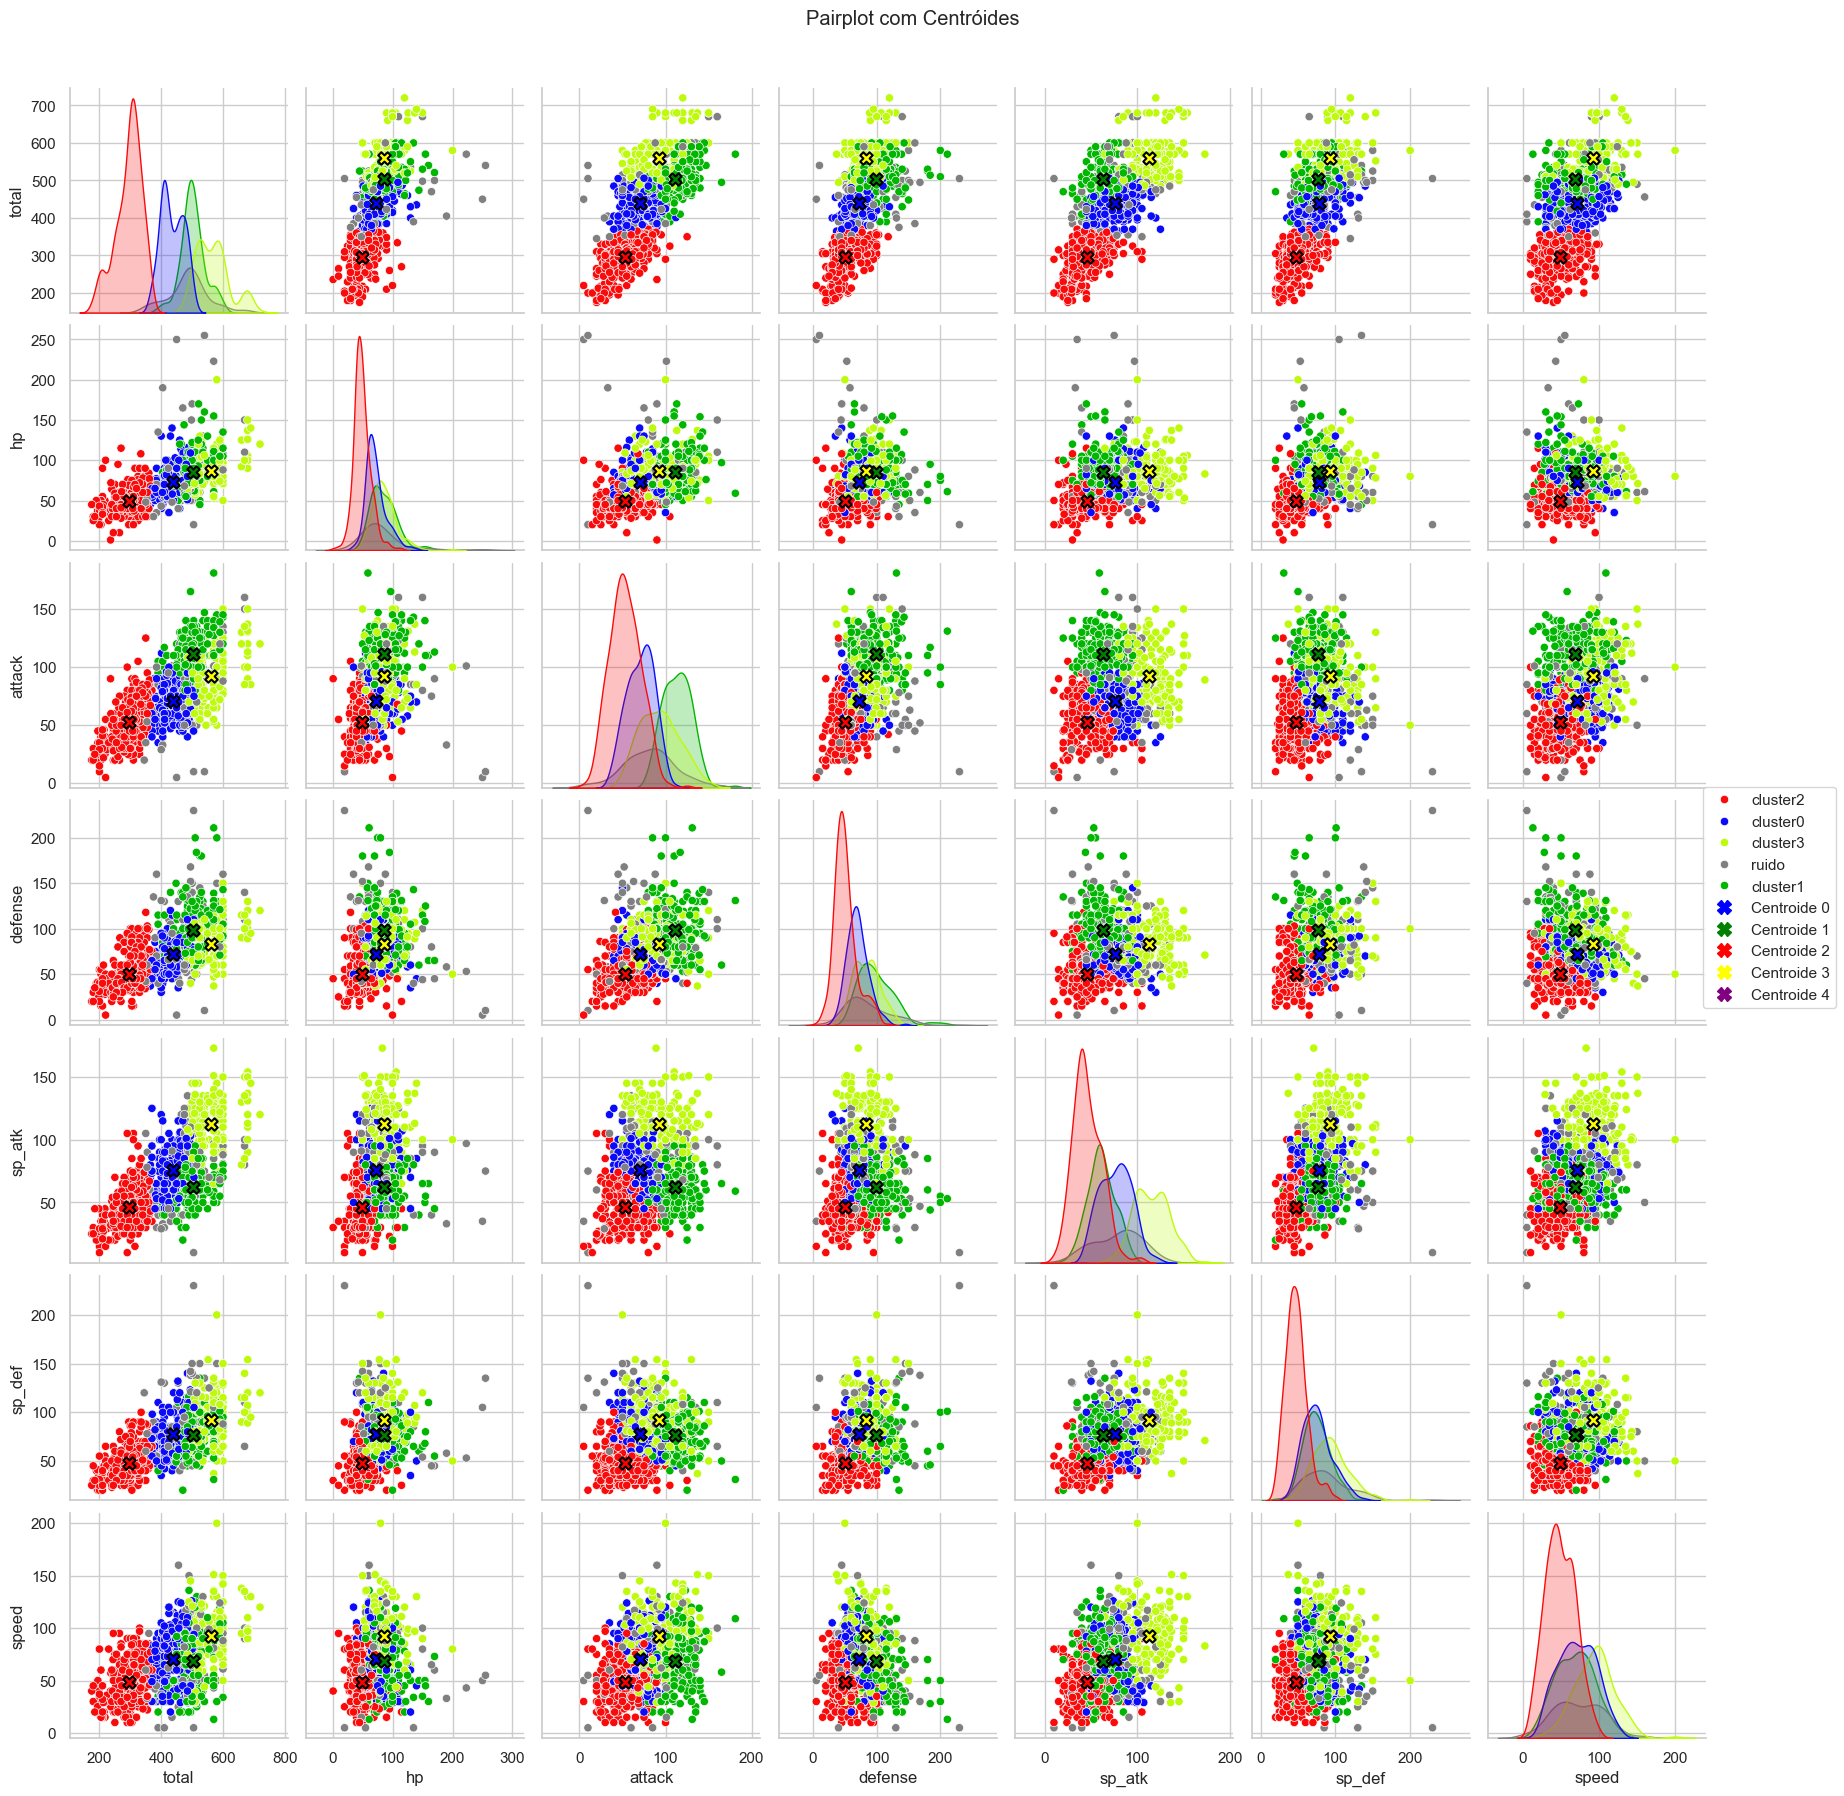

In [60]:
# Mostrando a separação de clusters, centroides e ruidos (zona de confusão)
df_plot = X.copy()
df_plot['classe'] = y

# Setando uma paleta de cores manualmente
palette = {
    'cluster0': "#0B0BFA",
    'cluster1': "#01B601",
    'cluster2': '#FA0B0B',
    'cluster3': "#BEFA0B",
    'cluster4': "#C20BFA",
    'ruido': 'gray'
}

g = sns.pairplot(df_plot, hue='classe', palette=palette, diag_kind='kde')

g.fig.suptitle("Pairplot com Centróides", y=1.03)

# Recuperando o scaler para inverter a normalização dos centroides
scaler = MinMaxScaler()
scaler.fit_transform(X)

centroides = scaler.inverse_transform(cent[-1])

cores_centroides = ['blue', 'green', 'red', 'yellow', 'purple']

for i, row in enumerate(g.axes):
    for j, ax in enumerate(row):
        if i == j:
            continue
        
        for k, c in enumerate(centroides):
            ax.scatter(
                c[j], c[i],
                c=cores_centroides[k],
                marker='X',
                s=80,
                edgecolors='black',
                linewidths=1.5
            )

handles = g._legend.legend_handles
labels = [t.get_text() for t in g._legend.texts]

for i, cor in enumerate(cores_centroides):
    handles.append(
        plt.Line2D(
            [0], [0],
            marker='X',
            color='w',
            markerfacecolor=cor,
            markeredgecolor=cor,
            markersize=10,
            label=f'Centroide {i}'
        )
    )
    labels.append(f'Centroide {i}')

g._legend.remove()
g.fig.legend(handles=handles, labels=labels, loc='center right', ncol=1)

plt.show()

# Análise dos Clusters

In [61]:
df_final = X.copy()
df_final['name'] = df['name']
df_final['classe'] = y
df_final.to_csv('pokedex_fuzzy.csv', index=False)
colunas = ['total', 'hp', 'attack', 'defense', 'sp_atk', 'sp_def', 'speed']

# Média por cluster
df_cluster = (
    df_final
    .groupby('classe')[colunas]
    .mean()
    .round(2)
    .reset_index()
)

df_cluster

,classe,total,hp,attack,defense,sp_atk,sp_def,speed
0,cluster0,435.45,71.88,70.75,69.57,76.51,75.66,71.08
1,cluster1,501.75,85.34,113.34,98.85,60.92,74.97,68.33
2,cluster2,294.22,48.96,53.00,50.14,45.93,47.29,48.90
3,cluster3,566.34,86.47,93.06,84.20,115.10,93.45,94.07
4,ruido,487.62,82.31,81.71,85.39,78.09,87.48,72.64


In [62]:
# Cluster 0 - 343 pokemons
# sp_atk, sp_def, hp, speed
# (Pika das galaxias)
# Composto por pokemons extremamentes fortes como 3° forma fortes, pseudo-lendários, lendários e míticos.


# Cluster 1 - 217 pokemons
# Equilibrados com atributos ~70
# Composto em geral por pokemons de 2° forma e pokemons que só tem 2 formas (ou pelo menos foram conforme lançamento).


# Cluster 2 - 178 pokemons
# -todos status --> Mais fracos/forma 1
# Composto em geral por pokemons de 1° forma e comuns


# Cluster 3 - 96 pokemons
# Pokemons com maior Atk
# Composto em geral por pokemons de 3° forma e 2° formas fortes


# Ruído - 191 pokemons
# Em geral estão na zona de confusão entre 2° e 3° forma e pseudo-lendários

# PCA

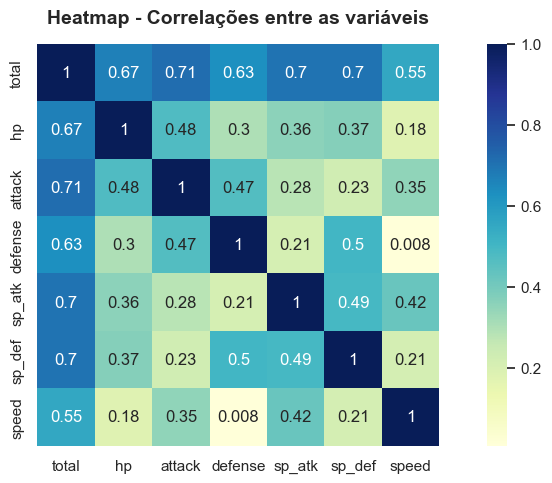

In [63]:
# Avaliando a correlação entre as vars 
plt.figure(figsize=(10,5))
plt.title('Heatmap - Correlações entre as variáveis', fontsize=14, pad=15, fontweight='bold')
ax=sns.heatmap(X.corr(),
               annot=True,
               cmap='YlGnBu',
               cbar_kws={"orientation":"vertical"}, )
ax.set_aspect("equal")
plt.tight_layout()

In [65]:
# Aplicando o PCA
pca = PCA()
resultado_pca=pca.fit_transform(scale(X.values))
resultado=pd.DataFrame({'cp1':resultado_pca[:,0],'cp2':resultado_pca[:,1],'cp3':resultado_pca[:,2], 'cp4':resultado_pca[:,3], 'cp5':resultado_pca[:,4], 'cp6':resultado_pca[:,5], 'cp7':resultado_pca[:,6]})

In [66]:
X.columns

Index(['total', 'hp', 'attack', 'defense', 'sp_atk', 'sp_def', 'speed'], dtype='object')

In [67]:
pca.components_

array([[ 0.52347757,  0.35758277,  0.37196596,  0.33195636,  0.36722576,
         0.37396326,  0.2735851 ],
       [ 0.0257434 , -0.1114387 , -0.08018245, -0.59228531,  0.35155016,
        -0.17385819,  0.68983578],
       [ 0.01449255,  0.25728517,  0.63687405, -0.02844381, -0.3982498 ,
        -0.58953223,  0.14500187],
       [-0.03260372,  0.78478135, -0.18292444, -0.43464642,  0.16842197,
        -0.03770832, -0.36178515],
       [-0.00298338, -0.2649747 ,  0.23984214,  0.0797167 ,  0.70599038,
        -0.43995386, -0.41703561],
       [-0.02907248, -0.25903028,  0.55513747, -0.54235237, -0.07839528,
         0.49703109, -0.27667431],
       [ 0.85040071, -0.20082397, -0.22458924, -0.22085217, -0.22365294,
        -0.20088638, -0.21655574]])

In [76]:
resultado

,cp1,cp2,cp3,cp4,cp5,cp6,cp7
0,-1.818234,0.073366,-0.773462,0.071673,0.247149,0.307121,-6.299821e-16
1,-0.352010,0.152598,-0.810617,0.075908,0.129840,0.217507,-2.458260e-16
2,1.669972,0.224993,-0.803887,0.044213,-0.001560,0.122016,5.248153e-16
3,-2.053171,0.729066,-0.262278,-0.291219,0.153132,0.075379,-8.923077e-16
4,-0.430631,0.835362,-0.349152,-0.151951,0.109512,-0.105881,-3.633631e-16
...,...,...,...,...,...,...,...
1020,2.810833,0.304263,-0.839676,1.577484,0.633614,-0.903710,4.644581e-16
1021,2.682327,0.782059,0.592091,-0.616452,-1.338404,0.582013,8.755660e-16
1022,2.730473,0.522206,-1.311089,0.016058,-0.006869,-0.575870,5.940777e-16
1023,0.431371,-0.626471,-0.381238,0.509984,-0.525761,-0.304699,3.866866e-17


In [75]:
# Avaliando os componentes principais
for i, cp in enumerate(pca.components_.round(2)):
    if i == 3: break
    print(f'CP{i+1} = {cp[0]}*total +    {cp[1]}*hp +    {cp[2]}*attack +   {cp[3]}*defense +    {cp[4]}*sp_atk +   {cp[5]}*sp_def +    {cp[6]}*speed')
    

CP1 = 0.52*total +    0.36*hp +    0.37*attack +   0.33*defense +    0.37*sp_atk +   0.37*sp_def +    0.27*speed
CP2 = 0.03*total +    -0.11*hp +    -0.08*attack +   -0.59*defense +    0.35*sp_atk +   -0.17*sp_def +    0.69*speed
CP3 = 0.01*total +    0.26*hp +    0.64*attack +   -0.03*defense +    -0.4*sp_atk +   -0.59*sp_def +    0.15*speed


CP1: O CP com maior explicação da variablidade dos dados, sendo o maior peso na variável total. Um CP1 alto indica um pokemon com atributos altos de maneira geral, com uma leve penalidade aos pokemons mais rápidos por ter um peso menor.

CP2: Busca visualizar pokemons mais rápidos porém mais papel. Pokemons mais rápidos e com mais sp_atck terão um CP alto caso tenham uma defesa baixa. Pokemons mais tank e com speed/ sp_atk mais alto terão um CP2 equilibrado (próximo de zero). E pokemons com defesa alta e speed/atk baixo terão um resultado mais negativo.

CP3: Um pokemon com mais atk, vida e velocidade ao mesmo tempo que yna defesa especial baixa terá um valor extremamente positivo. Pokemons com atk. speed e hp alto e sp_def alta tera um valor positivo mais baixo. E valores negativos indicam grande sp_def e atk, hp speed mais baixos.

In [69]:
# variância explicada dos CPs
pca.explained_variance_ratio_

array([5.20348239e-01, 1.57939764e-01, 1.26023060e-01, 9.60305088e-02,
       6.06208424e-02, 3.90375852e-02, 2.65010960e-17])

In [70]:
#variância explicada acumulada
np.cumsum(np.round(pca.explained_variance_ratio_,decimals=4)*100)

array([52.03, 67.82, 80.42, 90.02, 96.08, 99.98, 99.98])

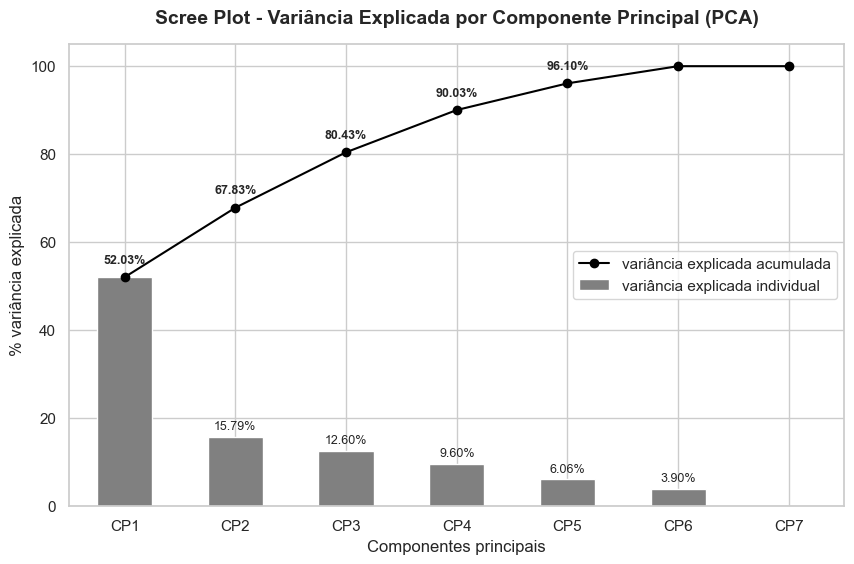

In [71]:
# Avaliando também com o gráfico da variância acumulada e individual
# variâncias acumuladas
tot = sum(pca.explained_variance_)
var_exp = [(i / tot)*100 for i in sorted(pca.explained_variance_, reverse=True)]
cum_var_exp = np.cumsum(var_exp)
# número de CPs gerados (k = p)
cp =['CP'+str(i+1) for i in range(len(pca.components_))]
# dataframe com as variâncias acumuladas para criar o scree plot
df_plot = pd.DataFrame({'cp': cp, 'var_exp': var_exp, 'cum_var_exp': cum_var_exp})
# scree plot com %
fig, ax = plt.subplots(figsize=(10, 6)) # Ajuste no tamanho para acomodar os novos textos
df_plot.plot.bar('cp', 'var_exp', color='gray', ax=ax, legend=False)
df_plot.plot.line('cp', 'cum_var_exp', color='black', marker='o', ax=ax) # Adicionado marcador de ponto na linha

# Adiciona o valor percentual acima de cada barra (individual)
for i, bar in enumerate(ax.patches):
    height = bar.get_height()
    if height > 1 and i > 0: 
        ax.annotate(f'{height:.2f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)
        
# Adiciona o valor percentual acima de cada ponto da linha (acumulada)
for i, val in enumerate(df_plot['cum_var_exp']):
    if val < 99.9 or i == 7:
        ax.annotate(f'{val:.2f}%',
                    xy=(i, val),
                    xytext=(0, 8),  
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.title('Scree Plot - Variância Explicada por Componente Principal (PCA)', fontsize=14, pad=15, fontweight='bold')
plt.legend(labels=['variância explicada acumulada', 'variância explicada individual'], loc='center right')
plt.ylabel('% variância explicada')
plt.xlabel('Componentes principais');

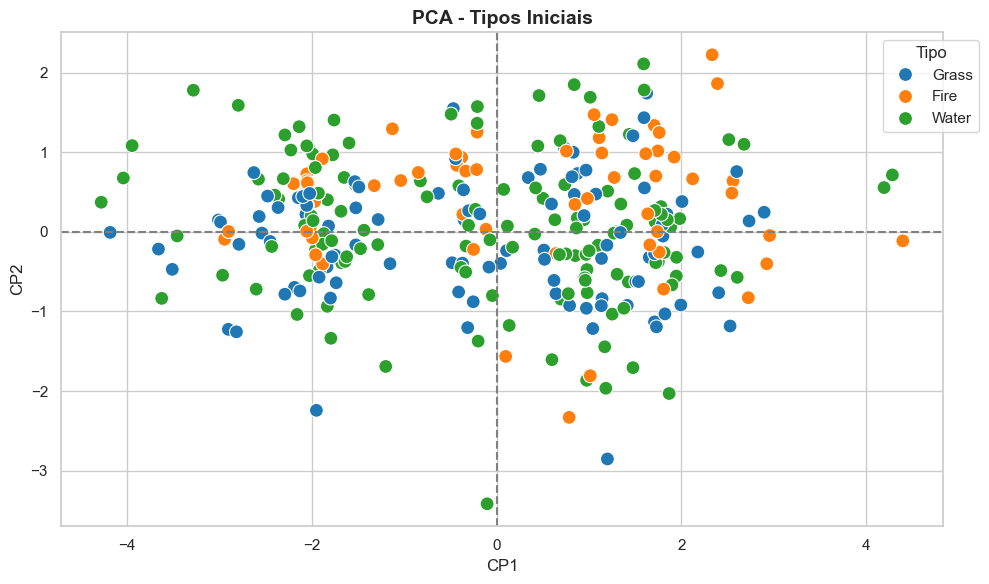

In [72]:
#separar entre fogo, agua, e grama
df_tipos = df[df['type_1'].isin(['Fire', 'Water', 'Grass'])]
resultado_tipo = resultado.loc[df_tipos.index].copy()
resultado_tipo['type_1'] = df_tipos['type_1'].values
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=resultado_tipo,
    x='cp1',
    y='cp2',
    hue='type_1',
    palette='tab10',
    s=100
)

plt.axhline(0, color='gray', linestyle='--')
plt.axvline(0, color='gray', linestyle='--')

plt.title('PCA - Tipos Iniciais', fontsize=14, fontweight='bold')
plt.xlabel('CP1')
plt.ylabel('CP2')

plt.legend(bbox_to_anchor=(1.05,1), title='Tipo')
plt.tight_layout()
plt.show()

In [79]:
import plotly.express as px

df_plot = pd.DataFrame({
    'PCA1': resultado_pca[:, 0],
    'PCA2': resultado_pca[:, 1],
    'PCA3': resultado_pca[:, 2],
    'Cluster': y.astype(str),

    'Pokedex': df['num_pokedex'],
    'Nome': df['name'],
    'Tipo 1': df['type_1'],
    'Tipo 2': df['type_2'],
    'Total': df['total'],
    'HP': df['hp'],
    'Attack': df['attack'],
    'Defense': df['defense'],
    'Sp. Atk': df['sp_atk'],
    'Sp. Def': df['sp_def'],
    'Speed': df['speed']
})

# ===============================
# Plot 3D interativo
# ===============================

fig = px.scatter_3d(
    df_plot,
    x='PCA1',
    y='PCA2',
    z='PCA3',
    color='Cluster',
    hover_data={
        'Pokedex': True,
        'Nome': True,
        'Tipo 1': True,
        'Tipo 2': True,
        'Total': True,
        'HP': True,
        'Attack': True,
        'Defense': True,
        'Sp. Atk': True,
        'Sp. Def': True,
        'Speed': True,

        # Não mostrar duplicado
        'PCA1': False,
        'PCA2': False,
        'PCA3': False
    },
    opacity=0.7,
    title='Fuzzy C-Means + PCA 3D',
    width=1100,
    height=800
)

# Ajustando tamanho dos pontos
fig.update_traces(marker=dict(size=5))

# Layout
fig.update_layout(
    scene=dict(
        xaxis_title='Componente Principal 1',
        yaxis_title='Componente Principal 2',
        zaxis_title='Componente Principal 3'
    )
)

# ===============================
# Variância explicada
# ===============================

print('Variância explicada por componente:')
print(pca.explained_variance_ratio_)

print(f'\nVariância total explicada: {pca.explained_variance_ratio_.sum():.4f}')

# ===============================
# Exibindo gráfico
# ===============================

fig.show()

Variância explicada por componente:
[0.52034824 0.15793976 0.12602306]

Variância total explicada: 0.8043


Caso gráfico 3d não rode: pip install nbformat

In [88]:
# DataFrame base
df_plot = pd.DataFrame({
    'CP1': resultado_pca[:, 0],
    'CP2': resultado_pca[:, 1],
    'Cluster': y.astype(str),

    # Ajustado para DataFrame W
    'Pertinencia': W.iloc[:, 0].round(4),

    'Nome': df['name'],
    'Tipo 1': df['type_1'],
    'Ataque': df['attack'],
    'Defesa': df['defense']
})

# Selecionando apenas 2 clusters
clusters_desejados = ['cluster0', 'cluster1']

df_filtrado = df_plot[
    df_plot['Cluster'].isin(clusters_desejados)
]

# Gráfico
fig = px.scatter(
    df_filtrado,
    x='CP1',
    y='CP2',
    color='Pertinencia',
    color_continuous_scale='Viridis',
    hover_data=[
        'Nome',
        'Tipo 1',
        'Ataque',
        'Defesa'
    ],
    title='Pertinência ao Cluster 0'
)

# Ajuste visual
fig.update_traces(
    marker=dict(
        size=7,
        line=dict(width=1, color='black')
    )
)

fig.update_layout(
    width=1000,
    height=700,
    xaxis_title='Componente Principal 1',
    yaxis_title='Componente Principal 2'
)

fig.show()